In [1]:
from glob import glob

Firstly, we need to read in all training data.

In [2]:
train_dataset = 'dataset/training/' 

In [3]:
glioma = glob(train_dataset + '/glioma_tumor/*.jpg')
meningioma = glob(train_dataset + '/meningioma_tumor/*.jpg')
pituitary = glob(train_dataset + '/pituitary_tumor/*.jpg')
no_tumor = glob(train_dataset + '/no_tumor/*.jpg')

We now need to preprocess images within each dataset and label them according to their classification.

In [4]:
x = [] # images
y = [] # labels for the images

In [5]:
import cv2
import numpy as np

In [6]:
for img in no_tumor:

    # read in the image
    img = cv2.imread(img)

    # convert image to grayscale
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # normalize the data
    img = img / 255

    # resize the image for uniformity
    img = cv2.resize(img, (256, 256))

    # compile the dataset of images
    x.append(img)

    # label each image accordingly and compile the dataset of labels
    y.append(0)

In [7]:
for img in glioma:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    x.append(img)
    y.append(1)

In [8]:
for img in meningioma:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    x.append(img)
    y.append(2)

In [9]:
for img in pituitary:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    x.append(img)
    y.append(3)

Convert the arrays into NumPy arrays so that we can use certain methods.

In [10]:
x = np.array(x)
y = np.array(y)

Since our data is ordered, we want to randomize it using scikit-learn.

In [11]:
from sklearn.utils import shuffle
x, y = shuffle(x, y, random_state=8)

Now with our data we can choose and create our model.

In [12]:
import tensorflow as tf

In [13]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(256, 256)),
    tf.keras.layers.Dense(128, activation='softmax')
])

In [14]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy() , 
              optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001), 
              metrics=['accuracy'])

In order to test this model we need to get our training data and perform the same preprocessing on the data.

In [15]:
test_dataset = 'dataset/testing/'

In [16]:
test_x = []
test_y = []

In [17]:
for img in no_tumor:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    test_x.append(img)
    test_y.append(0)

In [18]:
for img in glioma:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    test_x.append(img)
    test_y.append(1)

In [19]:
for img in meningioma:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    test_x.append(img)
    test_y.append(2)

In [20]:
for img in pituitary:
    img = cv2.imread(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))
    test_x.append(img)
    test_y.append(3)

In [21]:
test_x = np.array(test_x)
test_y = np.array(test_y)

In [22]:
from sklearn.utils import shuffle

In [23]:
test_x, test_y = shuffle(test_x, test_y, random_state=8)

In [24]:
history = model.fit(x, y, epochs=10, validation_data=(test_x, test_y))

Epoch 1/10
90/90 [==============================] - 10s 106ms/step - loss: 1.9708 - accuracy: 0.5453 - val_loss: 0.8161 - val_accuracy: 0.7247
Epoch 2/10
90/90 [==============================] - 2s 25ms/step - loss: 0.7902 - accuracy: 0.7108 - val_loss: 0.5138 - val_accuracy: 0.8213
Epoch 3/10
90/90 [==============================] - 2s 24ms/step - loss: 0.7340 - accuracy: 0.7544 - val_loss: 0.6618 - val_accuracy: 0.7530
Epoch 4/10
90/90 [==============================] - 2s 18ms/step - loss: 0.7150 - accuracy: 0.7672 - val_loss: 0.5648 - val_accuracy: 0.7854
Epoch 5/10
90/90 [==============================] - 2s 17ms/step - loss: 0.5052 - accuracy: 0.8146 - val_loss: 0.3486 - val_accuracy: 0.8648
Epoch 6/10
90/90 [==============================] - 1s 15ms/step - loss: 0.4102 - accuracy: 0.8477 - val_loss: 0.2134 - val_accuracy: 0.9334
Epoch 7/10
90/90 [==============================] - 1s 15ms/step - loss: 0.3356 - accuracy: 0.8686 - val_loss: 0.3249 - val_accuracy: 0.8718
Epoch 8/10


With this working model, we can evaluate the model and make our observations via the following.

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

90/90 [==============================] - 0s 4ms/step


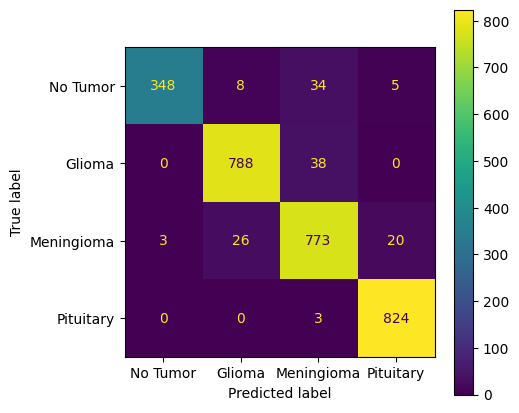

In [26]:
y_pred = model.predict(test_x)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Tumor', 'Glioma', 'Meningioma', 'Pituitary'])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax)
plt.show()


Finally, we can use our model to make predictions on images outside of our dataset through the following.

In [27]:
def make_prediction(image_path):
    # preprocess the image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img / 255
    img = cv2.resize(img, (256, 256))

    # reshape the image to match the input shape of the model
    img = np.reshape(img, (1, 256, 256))

    # make the prediction
    predictions = model.predict(img)
    predictions = np.argmax(predictions, axis=1)

    print(f'The predicted class is: {predictions}')

In [28]:
make_prediction('dataset/glioma.jpg')

1/1 [==============================] - 0s 19ms/step
The predicted class is: [1]


In [29]:
make_prediction('dataset/meningioma.png')

1/1 [==============================] - 0s 39ms/step
The predicted class is: [2]
